##Setup: Imports and Drive Connection
Okay, first, we'll import all the libraries we need. This time, we're importing EfficientNetB0 from tensorflow.keras.applications instead of ResNet50. We'll also connect our Google Drive

In [ ]:
# here we are importing all the required libraries
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, RandomFlip, RandomRotation
from tensorflow.keras.models import Model

# here we are importing efficientnetb0 as the main model for this experiment
from tensorflow.keras.applications import EfficientNetB0

import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# here we are connecting to google drive
print("connecting to google drive...")
from google.colab import drive
drive.mount('/content/drive')
print("drive mounted successfully")


Connecting to Google Drive...
Mounted at /content/drive
Drive mounted successfully.


##Load Data: Unzip and Define Paths
Same as our last run, we'll unzip our DATA.zip file. We're keeping the -o (overwrite) flag so it doesn't ask us to replace files.

We'll define all our main variables here. We're keeping the epochs the same (15 + 10) so we can make a fair comparison with our ResNet mode

In [ ]:
# here we are unzipping the dataset from google drive
print("unzipping the data zip file from drive...")
ZIP_PATH = "/content/drive/MyDrive/DATA.zip"
!unzip -o -q {ZIP_PATH} -d "/content/"
print("data is unzipped and ready in content")

# here we are defining the main project variables
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS_STAGE_1 = 15
EPOCHS_STAGE_2 = 10

# here we are defining the paths to our training validation and testing folders
TRAIN_DIR = "/content/DATA/Training(70%)"
VALID_DIR = "/content/DATA/Validation(20%)"
TEST_DIR = "/content/DATA/Testing(10%)"


Unzipping the DATA.zip file from Drive...
Data is unzipped and ready in /content/.


##Create Data Pipelines (Initial Load)
Here, we'll load the datasets from their folders using the Keras utility. We need to load train_dataset at this stage so we can read its labels for the class weighting step

In [ ]:
# here we are loading the training validation and test datasets
print("loading training validation and test datasets...")

# here we are loading the training dataset first to get the class labels
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, label_mode="categorical", seed=123,
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)

# here we are loading the validation dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR, label_mode="categorical", seed=123,
    image_size=IMAGE_SIZE, batch_size=BATCH_SIZE
)

# here we are loading the test dataset without shuffling
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, label_mode="categorical", image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, shuffle=False
)

# here we are printing the class names to confirm
class_names = train_dataset.class_names
print(f"our class names are: {class_names}")


Loading Training, Validation, and Test datasets...
Found 2297 files belonging to 4 classes.
Found 573 files belonging to 4 classes.
Found 394 files belonging to 4 classes.
Our class names are: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


##Calculate Class Weights
This is our key improvement. We're using the fast np.concatenate method to get all the training labels. Then, we use scikit-learn to calculate the balanced weights. This fixes our 'no_tumor' class imbalance, which we proved is essential

In [ ]:
# here we are calculating the class weights using the fast method
print("calculating class weights fast method...")

# here we are getting all the labels from the training dataset
train_labels = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in train_dataset])

# here we are calculating balanced class weights using sklearn
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# here we are converting the weights into a dictionary for tensorflow
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# here we are printing the calculated class weights
print(f"calculated weights: {class_weight_dict}")


Calculating class weights (fast method)...
Calculated weights: {0: np.float64(0.8687594553706506), 1: np.float64(0.8727203647416414), 2: np.float64(1.817246835443038), 3: np.float64(0.8674471299093656)}


##Optimize Data Pipelines
Now that we have our weights, we can optimize all three datasets with .cache() and .prefetch(). This makes the training process much faster by pre-loading data for the GPU

In [ ]:
# here we are optimizing the data pipelines for faster performance
print("optimizing data pipelines...")
AUTOTUNE = tf.data.AUTOTUNE

# here we are applying cache and prefetch to improve loading speed
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)


Optimizing data pipelines...


##Stage 1: Initial Training (EfficientNet)
Time to build our new model. We're loading EfficientNetB0 and freezing it. We'll train just the head, and most importantly, we'll pass our class_weight_dict to model.fit()

In [ ]:
# here we are building the efficientnetb0 model
print("building the efficientnetb0 model...")

# here we are loading the efficientnetb0 base model with imagenet weights
base_model = EfficientNetB0(weights='imagenet', include_top=False,
                            input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

# here we are freezing the base model layers for stage 1
print("freezing the efficientnetb0 base layers for stage 1")
base_model.trainable = False

# here we are creating the model architecture
inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = RandomFlip('horizontal')(inputs)
x = RandomRotation(0.1)(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)
model = Model(inputs, outputs)

# here we are compiling the model for stage 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# here we are starting stage 1 training with class weights
print("starting model training stage 1 head only with weights")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_STAGE_1,
    class_weight=class_weight_dict,
    verbose=1
)

# here we are finishing the training for stage 1
print("stage 1 training complete")


Building the EfficientNetB0 model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Freezing the EfficientNetB0 base layers for Stage 1.

--- Starting Model Training (Stage 1: Head Only, WITH WEIGHTS) ---
Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 195ms/step - accuracy: 0.4678 - loss: 1.1862 - val_accuracy: 0.7225 - val_loss: 0.7397
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 84ms/step - accuracy: 0.7274 - loss: 0.6883 - val_accuracy: 0.7557 - val_loss: 0.6489
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.7614 - loss: 0.5991 - val_accuracy: 0.7853 - val_loss: 0.5813
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.7907 - loss: 0.5381 - val_accuracy: 0.7923 - val_loss: 0.5535
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.7945 - loss: 0.5128 - val_accuracy: 0.7941 - val_loss: 0.5218
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.8037 - loss: 0.4750 - val_accuracy: 0.8098 - val_loss: 0.5166
Epoch 7/15
72/72 ━━━━━━━━━━

##Stage 2: Fine-Tuning (EfficientNet)
Now for Stage 2. We'll unfreeze the top 30 layers of EfficientNetB0. Then we re-compile with a very low learning rate (1e-5) to avoid breaking the learned weights. We pass the class_weight_dict again to model.fit()

In [ ]:
# here we are starting stage 2 fine tuning with class weights
print("starting model training stage 2 fine tuning with weights")
print("unfreezing the top 30 layers of the model...")

# here we are unfreezing only the top 30 layers for fine tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# here we are recompiling the model for fine tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# here we are confirming the model has been recompiled
print("model recompiled for fine tuning")
model.summary()

# here we are continuing the training for fine tuning
print("continuing training to fine tune the unfrozen layers...")
history_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_STAGE_1 + EPOCHS_STAGE_2,
    initial_epoch=history.epoch[-1],
    class_weight=class_weight_dict,
    verbose=1
)

# here we are finishing the fine tuning stage
print("stage 2 fine tuning complete")



--- Starting Model Training (Stage 2: Fine-Tuning, WITH WEIGHTS) ---
Unfreezing the top 30 layers of the model...
--- Model Re-compiled for Fine-Tuning ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 1,501,284 (5.73 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

Continuing training to fine-tune the unfrozen layers...
Epoch 15/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 161ms/step - accuracy: 0.6612 - loss: 0.7882 - precision: 0.7176 - recall: 0.5886 - val_accuracy: 0.8360 - val_loss: 0.4363 - val_precision: 0.8614 - val_recall: 0.8133
Epoch 16/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.7474 - loss: 0.5990 - precision: 0.7973 - recall: 0.6981 - val_accuracy: 0.8290 - val_loss: 0.4579 - val_precision: 0.8574 - val_recall: 0.7976
Epoch 17/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.7803 - loss: 0.5524 - precision: 0.8133 - recall: 0.7173 - val_accuracy: 0.8185 - val_loss: 0.4685 - val_precision: 0.8493 - val_recall: 0.7871
Epoch 18/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.8028 - loss: 0.4908 - precision: 0.8397 - recall: 0.7515 - val_accuracy: 0.8185 - val_loss: 0.4666 - val_precision: 0.8558 - val_recall: 0.7871
Epoch 19/25
72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.8261 - loss: 0.4533 - precision

##Final Evaluation, Plotting, and Saving



--- Evaluating the EFFICIENTNET Fine-Tuned Model on the Test Set ---
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.4445 - loss: 1.9393 - precision: 0.4690 - recall: 0.3972



--- EFFICIENTNET Fine-Tuned Model Test Results ---
Test Loss: 1.1545
Test Accuracy: 0.6447
Test Precision: 0.6850
Test Recall: 0.6015
Test F1-Score: 0.6405

--- Saving the model to Google Drive ---
WEIGHTED Fine-Tuned EfficientNet model saved.

--- Generating Training Plots ---


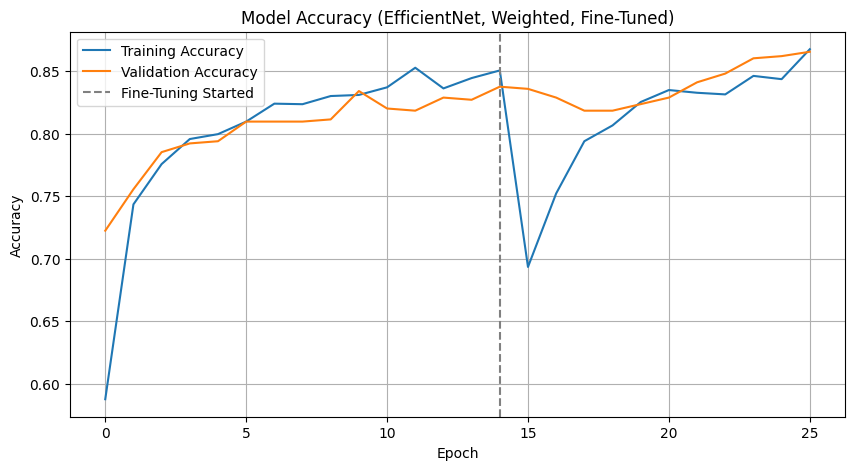

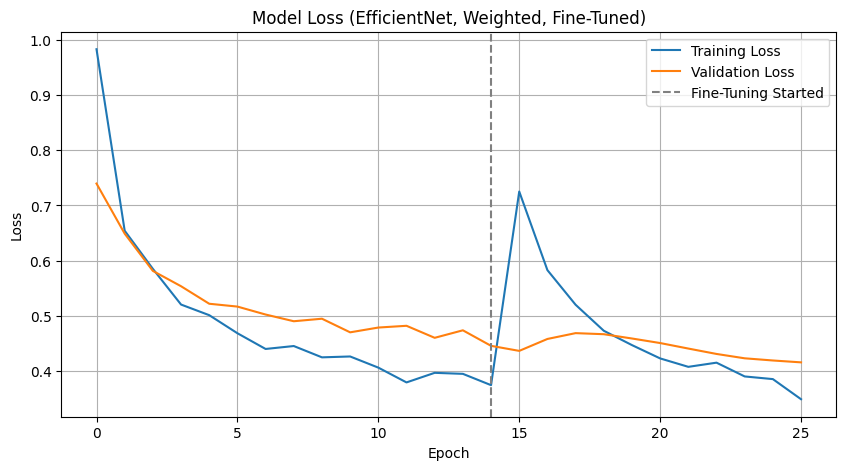

--- All steps complete! ---


In [ ]:
# here we are evaluating the fine tuned efficientnet model
print("evaluating the efficientnet fine tuned model on the test set")
results = model.evaluate(test_dataset, verbose=1)

# here we are calculating all the performance metrics
metrics = {}
metrics['loss'] = results[0]
metrics['accuracy'] = results[1]
metrics['precision'] = results[2]
metrics['recall'] = results[3]

# here we are calculating the f1 score
if (metrics['precision'] + metrics['recall']) > 0:
    metrics['f1_score'] = 2 * (metrics['precision'] * metrics['recall']) / (metrics['precision'] + metrics['recall'])
else:
    metrics['f1_score'] = 0.0

# here we are printing the final test results
print("efficientnet fine tuned model test results")
print(f"test loss: {metrics['loss']:.4f}")
print(f"test accuracy: {metrics['accuracy']:.4f}")
print(f"test precision: {metrics['precision']:.4f}")
print(f"test recall: {metrics['recall']:.4f}")
print(f"test f1 score: {metrics['f1_score']:.4f}")

# here we are saving the final model to google drive
print("saving the model to google drive")
os.makedirs("/content/drive/MyDrive/MODELS", exist_ok=True)
model.save("/content/drive/MyDrive/MODELS/efficientnet_finetuned_weighted.h5")
print("weighted fine tuned efficientnet model saved")

# here we are generating training plots
print("generating training plots")

# here we are combining the history from both training stages
history_full = {}
history_full['accuracy'] = history.history['accuracy'] + history_finetune.history['accuracy']
history_full['val_accuracy'] = history.history['val_accuracy'] + history_finetune.history['val_accuracy']
history_full['loss'] = history.history['loss'] + history_finetune.history['loss']
history_full['val_loss'] = history.history['val_loss'] + history_finetune.history['val_loss']

# here we are plotting the accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(history_full['accuracy'], label='training accuracy')
plt.plot(history_full['val_accuracy'], label='validation accuracy')
plt.axvline(x=EPOCHS_STAGE_1 - 1, color='grey', linestyle='--', label='fine tuning started')
plt.title('model accuracy efficientnet weighted fine tuned')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/efficientnet_accuracy_plot.png')
plt.show()

# here we are plotting the loss graph
plt.figure(figsize=(10, 5))
plt.plot(history_full['loss'], label='training loss')
plt.plot(history_full['val_loss'], label='validation loss')
plt.axvline(x=EPOCHS_STAGE_1 - 1, color='grey', linestyle='--', label='fine tuning started')
plt.title('model loss efficientnet weighted fine tuned')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/efficientnet_loss_plot.png')
plt.show()

# here we are confirming that all steps are done
print("all steps complete")
